# LoRA: adapt, save and merge low-rank updates

CPU companion; no accelerator is required. TPU execution not validated.

- Separate the frozen base from trainable adapters
- Understand initialization and the first gradient
- Verify the changed-condition exercise and explain the limits of this fixture.

A trained dense layer already works, but the task changes. Can we fit the change while leaving the original weights untouched? We will first train a base, then learn and audit a low-rank update.

## The idea

LoRA parameterizes a weight change as two smaller matrices. It reduces trainable parameter and optimizer-state counts for selected layers; it does not eliminate activation memory or guarantee a latency improvement. Our changed target is deliberately rank one, which makes the adaptation test exact and interpretable.

## Separate the frozen base from trainable adapters

For input-by-output weights $W_0$, let $A$ have shape $(d,r)$ and $B$ shape $(r,k)$. Compute the base output plus the scaled adapter output. Only the adapter tuple is passed to the gradient function. Keep a copy of $W_0$ and compare it exactly after training.

$$
Y=XW_0+\frac{\alpha}{r}XAB
$$

## Understand initialization and the first gradient

Initialize $A$ randomly and $B$ to zero. The initial adapter output is zero, so predictions match the base. At this first step the gradient with respect to $A$ is zero because it multiplies $B$; the gradient for $B$ can be nonzero. Initializing both factors to zero would block both gradients for this bilinear update.

## Count the right kind of savings

The fixture has $6\times4=24$ base weights and rank $1$, giving $6+4=10$ trainable adapter scalars. The base remains resident. Real memory includes gradients, optimizer state, activations and runtime buffers. A low-bit frozen base plus adapters also needs a quantization policy and supported kernels; this lab does not implement QLoRA.

## Merge only under an explicit serving contract

Without adapter dropout, an inference merge computes $W_{\mathrm{merged}}=W_0+(\alpha/r)AB$. Check outputs on changed inputs before deleting or replacing anything. Keep the unmerged base, adapter and scaling metadata; a second accidental merge adds the update twice. Packed or quantized bases require dequantization/requantization rules rather than a blind in-place add.

## Save the adaptation identity

An adapter artifact needs the base checkpoint hash, target module names, rank, alpha, dtype and exact factor arrays. Match all of these on load. Compare the adapted task and original task separately; low rank does not prevent forgetting, and this rank-one teacher does not predict the rank required by a real task.

## Run the example

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

def lora_forward(x, base, a, b, alpha=1.):
    rank = a.shape[1]
    return x @ base + (alpha/rank) * (x @ a @ b)

x=jnp.asarray(np.random.default_rng(4).normal(size=(24,6)),jnp.float32)
source_w=jnp.arange(24,dtype=jnp.float32).reshape(6,4)/40
base=jnp.zeros_like(source_w)
base_step=jax.jit(jax.grad(lambda w:jnp.mean((x@w-x@source_w)**2)))
for _ in range(150):base=base-.15*base_step(base)
assert float(jnp.mean((x@base-x@source_w)**2))<1e-4
frozen=np.asarray(base).copy()
u=jnp.array([[.2],[-.3],[.1],[.2],[-.1],[.4]])
v=jnp.array([[.5,-.2,.3,.1]])
target=x@(base+u@v)
a=jax.random.normal(jax.random.key(4),(6,1))*.1;b=jnp.zeros((1,4));params=(a,b)
loss=lambda ab:jnp.mean((lora_forward(x,base,*ab,alpha=1.)-target)**2)
step=jax.jit(jax.value_and_grad(loss));history=[]
initial_grads=step(params)[1]
np.testing.assert_array_equal(initial_grads[0],np.zeros((6,1)))
assert np.linalg.norm(initial_grads[1])>0
for _ in range(250):
    value,g=step(params);history.append(float(value));params=jax.tree.map(lambda a,b:a-.4*b,params,g)
a,b=params
assert history[-1]<history[0]*.02
np.testing.assert_array_equal(base,frozen)
merged=base+a@b
np.testing.assert_allclose(lora_forward(x,base,a,b),x@merged,rtol=1e-5,atol=1e-6)
print('LoRA initial/final:',history[0],history[-1],'; trainable:',a.size+b.size,'base:',base.size)


LoRA initial/final: 0.043869297951459885 2.466217665642034e-07 ; trainable: 10 base: 24


Expected: The trained base stays unchanged; 10 adapter scalars fit the rank-one change and merge equivalently.

## LoRA: adapt, save and merge low-rank updates — recorded experiment

Predict: Predict what should change during training and what this curve cannot establish.

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
visual_data={'kind':'line','xlabel':'completed parameter updates before measurement','ylabel':'training objective','series':[{'label':'recorded CPU training loss','x':list(range(len(history))),'y':history}]}
for panel in visual_data.get('panels',[visual_data]):
    panel['x']=panel['series'][0]['x']


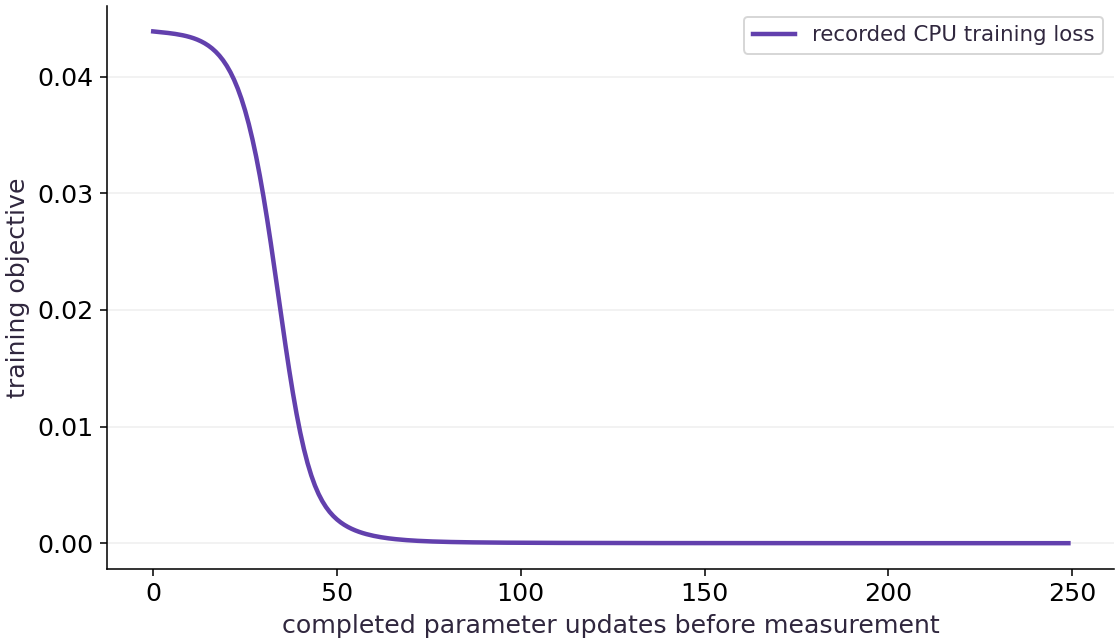

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The plot is adaptation MSE before each update, falling from about $0.044$ to below $10^{-6}$. It does not include the preceding base-training run. The target update was constructed to have rank one, so this is an achievable representation test rather than a universal LoRA performance claim.

### Connect it to the computation

The first adapter update affects B; later updates can train both factors. The unchanged-base assertion, reloaded adapter and new-input merge comparison are separate evidence from the falling training line.

## Show why two zero factors cannot start learning

Predict: If both factors start at zero, can this first-order update move either one?

In [4]:
zero=(jnp.zeros_like(a),jnp.zeros_like(b))
zero_grad=jax.grad(loss)(zero)
assert all(np.array_equal(np.asarray(g),np.zeros(g.shape)) for g in zero_grad)
print('Both zero factors produce zero first gradients.')

Both zero factors produce zero first gradients.


Expected: Both factor gradients are exactly zero.

Each factor’s derivative contains the other factor. Randomizing one and zeroing the other preserves the initial base output without blocking the whole update.

## Your exercise

Save both adapter factors and their rank/scaling metadata, reload them and check merged versus unmerged predictions.

In [5]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [6]:
import tempfile
from pathlib import Path
with tempfile.TemporaryDirectory() as folder:
    path=Path(folder)/'adapter.npz'
    np.savez(path,a=np.asarray(a),b=np.asarray(b),alpha=np.array(1.),rank=np.array(1))
    with np.load(path,allow_pickle=False) as z:
        assert int(z['rank'])==z['a'].shape[1]
        np.testing.assert_allclose(lora_forward(x,base,z['a'],z['b'],float(z['alpha'])),x@merged,atol=1e-6,rtol=1e-5)
print('Adapter round trip and merge checked.')

Adapter round trip and merge checked.


## Check the merge on new inputs · Transfer

Draw a new input batch and compare the merged layer with the adapter path.

Hint: The equivalence is algebraic, so a new input should still agree.

In [7]:
# Write your attempt here.

## Reference reasoning

The second check detects an operational merge error that training loss alone would not reveal.

In [8]:
new_x=jnp.asarray(np.random.default_rng(91).normal(size=(7,6)),jnp.float32)
np.testing.assert_allclose(lora_forward(new_x,base,a,b),new_x@merged,atol=1e-6,rtol=1e-5)
assert np.linalg.norm(np.asarray(new_x@(base+2*a@b)-new_x@merged))>1e-3
print('New-input merge passes; accidental double merge changes outputs.')

New-input merge passes; accidental double merge changes outputs.


## Checkpoint

Does LoRA require updating the base weights during adapter training?

1. No. The base is frozen; the selected adapter parameters receive updates.
2. A lower training loss by itself proves the full application is ready.
3. Matching shapes alone establishes the required behavior.

## Diagnose

If neither factor moves, inspect initialization. If merged predictions drift, check factor orientation, rank scaling, dropout, base identity and accidental repeated merges.

## Evidence

Keep base-training evidence, unchanged base arrays, adapter factors/rank/alpha, initial-gradient checks and reloaded/new-input merge parity.

## Primary references

- [LoRA](https://arxiv.org/abs/2106.09685)